In [1]:
!pip uninstall pingouin -q
!pip install git+https://github.com/raphaelvallat/pingouin.git@main -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import modules and functions
import numpy as np
import pandas as pd
import seaborn as sns
import pingouin as pg

In [4]:
# load the dataset from the google drive folder
data = pd.read_csv('/content/drive/MyDrive/data_updated.csv')
#

In [5]:
data.head()

,StartDate,EndDate,RecordedDate,ResponseId,DistributionChannel,student_status,concept_familiarity,treatment,verification,real_world_tendency,attention_check_AI,attention_check_verify,AI_usage
0,Start Date,End Date,Recorded Date,Response ID,Distribution Channel,Are you currently enrolled as a student at a c...,How familiar are you with subscription busines...,NaN,What would you do next?,How likely would you be to actually re-read th...,Did the AI assistant disclose that the text wa...,The AI assistant encouraged me to verify key p...,"How often do you use AI tools (e.g., ChatGPT) ..."
1,2/25/2026,2/25/2026,2/25/2026,R_73rKfeoWMDvdIC5,qr,1,3,0.0,1,2,2,4,3
2,2/25/2026,2/25/2026,2/25/2026,R_62x02ysqePsnlG7,anonymous,1,3,1.0,1,2,2,1,5
3,2/25/2026,2/25/2026,2/25/2026,R_1HDFSeG2vnKNhJL,anonymous,1,2,1.0,0,4,2,3,5
4,2/25/2026,2/25/2026,2/25/2026,R_1WIMdOCVwWCDrYR,anonymous,1,2,0.0,1,4,2,2,5


**Data preprocessing**

Since there are two lines of text in
the table header, we need to remove the second line for data analysis

In [9]:
data = data[data["ResponseId"] != "Response ID"].copy()

# 2) Convert the key columns to numerical values
num_cols = [
    "student_status","concept_familiarity","treatment","verification",
    "real_world_tendency","attention_check_AI","attention_check_verify","AI_usage"
]
for c in num_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce")

print(data.shape)
print(data["treatment"].value_counts(dropna=False))
print(data["verification"].value_counts(dropna=False))

(73, 13)
treatment
1.0    38
0.0    35
Name: count, dtype: int64
verification
1    38
0    35
Name: count, dtype: int64


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73 entries, 1 to 73
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   StartDate               73 non-null     object 
 1   EndDate                 73 non-null     object 
 2   RecordedDate            73 non-null     object 
 3   ResponseId              73 non-null     object 
 4   DistributionChannel     73 non-null     object 
 5   student_status          73 non-null     int64  
 6   concept_familiarity     73 non-null     int64  
 7   treatment               73 non-null     float64
 8   verification            73 non-null     int64  
 9   real_world_tendency     73 non-null     int64  
 10  attention_check_AI      73 non-null     int64  
 11  attention_check_verify  73 non-null     int64  
 12  AI_usage                73 non-null     int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 8.0+ KB


<Axes: xlabel='concept_familiarity', ylabel='Count'>

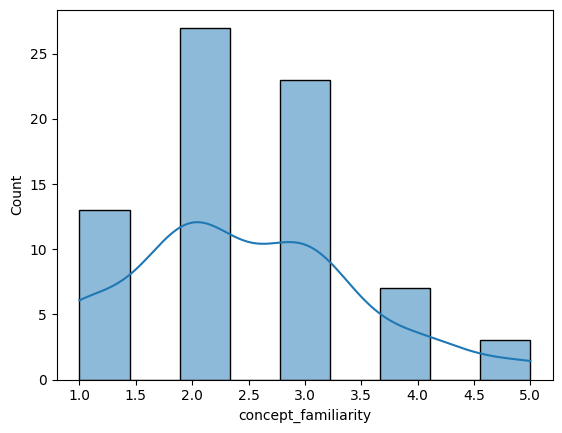

In [11]:
# create distribution of concept_faimilarity
# ensure the x-axis is the values from the concept_familiarity

sns.histplot(data['concept_familiarity'], kde=True)

### AI Usage Frequency Analysis

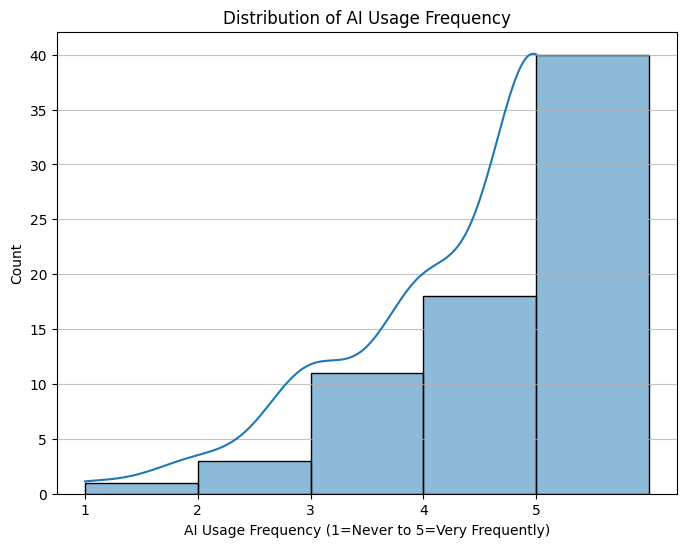

In [14]:
import matplotlib.pyplot as plt

# Create a histogram for 'AI_usage_frequency'
plt.figure(figsize=(8, 6))
sns.histplot(data['AI_usage'], kde=True, bins=range(1, data['AI_usage'].max() + 2), edgecolor='black')
plt.title('Distribution of AI Usage Frequency')
plt.xlabel('AI Usage Frequency (1=Never to 5=Very Frequently)')
plt.ylabel('Count')
plt.xticks(range(1, data['AI_usage'].max() + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

In [15]:
# Display descriptive statistics for 'AI_usage_frequency'
display(data['AI_usage'].describe())

,AI_usage
count,73.000000
mean,4.273973
std,0.961195
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [16]:
# Display value counts for each frequency level
display(data['AI_usage'].value_counts().sort_index())

,count
AI_usage,
1,1
2,3
3,11
4,18
5,40


**Randomization Check**

In [26]:
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
# Treat share test: is treat share = 0.5 ?
count = int(data["treatment"].sum())
nobs = data.shape[0]
z, p = proportions_ztest(count, nobs, value=0.5)
print("N =", nobs)
print("Treat count =", count, "Control count =", nobs - count)
print("Treat share =", count/nobs, "z =", z, "p =", p)



N = 73
Treat count = 38 Control count = 35
Treat share = 0.5205479452054794 z = 0.3514203189935144 p = 0.7252730409205124


In [29]:
import pandas as pd
from scipy.stats import ttest_ind
covs = ["student_status", "concept_familiarity", "AI_usage"]

for c in covs:
    g1 = data[data["treatment"] == 1][c].dropna()
    g0 = data[data["treatment"] == 0][c].dropna()

    print("\n", c)
    print("mean (T=1):", round(g1.mean(), 3))
    print("mean (T=0):", round(g0.mean(), 3))

    # If this variable remains unchanged, do not conduct a t-test
    if g1.nunique() <= 1 and g0.nunique() <= 1:
        print("constant -> skip t-test")
    else:
        t, p = ttest_ind(g1, g0, equal_var=False)
        print("p-value:", round(p, 4))


 student_status
mean (T=1): 1.0
mean (T=0): 1.0
constant -> skip t-test

 concept_familiarity
mean (T=1): 2.684
mean (T=0): 2.2
p-value: 0.0424

 AI_usage
mean (T=1): 4.289
mean (T=0): 4.257
p-value: 0.8883


In [38]:
# balance check (optional)
import pandas as pd
from scipy.stats import ttest_ind
covs = ["student_status", "concept_familiarity", "AI_usage"]
for c in covs:
    g1 = data[data["treatment"] == 1][c].dropna()
    g0 = data[data["treatment"] == 0][c].dropna()

    print("\n", c)
    print("mean (T=1):", round(g1.mean(), 3))
    print("mean (T=0):", round(g0.mean(), 3))
    if g1.nunique() <= 1 and g0.nunique() <= 1:
        print("constant -> skip t-test")
    else:
        t, p = ttest_ind(g1, g0, equal_var=False)
        print("p-value:", round(p, 4))


 student_status
mean (T=1): 1.0
mean (T=0): 1.0
constant -> skip t-test

 concept_familiarity
mean (T=1): 2.684
mean (T=0): 2.2
p-value: 0.0424

 AI_usage
mean (T=1): 4.289
mean (T=0): 4.257
p-value: 0.8883


**Primary Treatment Analysis-Main treatment effect on verification**

In [27]:
!pip install pyfixest

In [33]:
import pyfixest as pf

m1 = pf.feols("verification ~ treatment", data=data, vcov="HC1")
m1.summary()

###

Estimation:  OLS
Dep. var.: verification, Fixed effects: 0
Inference:  HC1
Observations:  73

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| Intercept     |      0.429 |        0.085 |     5.053 |      0.000 |  0.259 |   0.598 |
| treatment     |      0.177 |        0.117 |     1.512 |      0.135 | -0.056 |   0.410 |
---
RMSE: 0.492 R2: 0.031 


Adding covariates improves accuracy

In [20]:
m2 = pf.feols(
    "verification ~ treatment + student_status + concept_familiarity + AI_usage",
    data=data,
    vcov="HC1"
)
m2.summary()

/usr/local/lib/python3.12/dist-packages/pyfixest/estimation/feols_.py:2847: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['student_status'].
            
  warnings.warn(


###

Estimation:  OLS
Dep. var.: verification, Fixed effects: 0
Inference:  HC1
Observations:  73

| Coefficient         |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| Intercept           |      1.192 |        0.240 |     4.958 |      0.000 |  0.712 |   1.671 |
| treatment           |      0.224 |        0.112 |     1.991 |      0.050 | -0.000 |   0.448 |
| concept_familiarity |     -0.088 |        0.048 |    -1.834 |      0.071 | -0.184 |   0.008 |
| AI_usage            |     -0.134 |        0.050 |    -2.663 |      0.010 | -0.234 |  -0.034 |
---
RMSE: 0.468 R2: 0.121 


B.Treatment effect on RealWorld tendency

In [21]:
m3 = pf.feols(
    "verification ~ treatment + real_world_tendency",
    data=data,
    vcov="HC1"
)
m3.summary()

###

Estimation:  OLS
Dep. var.: verification, Fixed effects: 0
Inference:  HC1
Observations:  73

| Coefficient         |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| Intercept           |      0.203 |        0.183 |     1.112 |      0.270 | -0.161 |   0.567 |
| treatment           |      0.173 |        0.117 |     1.482 |      0.143 | -0.060 |   0.405 |
| real_world_tendency |      0.063 |        0.047 |     1.331 |      0.188 | -0.032 |   0.158 |
---
RMSE: 0.486 R2: 0.052 


**C.Consistency Check**

In [22]:
data_pass = data[(data["attention_check_AI"] == 1) & (data["attention_check_verify"] >= 4)].copy()

m_pass = pf.feols(
    "verification ~ treatment + student_status + concept_familiarity + AI_usage",
    data=data_pass,
    vcov="HC1"
)
m_pass.summary()

###

Estimation:  OLS
Dep. var.: verification, Fixed effects: 0
Inference:  HC1
Observations:  22

| Coefficient         |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| Intercept           |      0.448 |        0.824 |     0.544 |      0.593 | -1.283 |   2.178 |
| treatment           |      0.435 |        0.247 |     1.763 |      0.095 | -0.083 |   0.954 |
| concept_familiarity |     -0.194 |        0.103 |    -1.890 |      0.075 | -0.410 |   0.022 |
| AI_usage            |      0.084 |        0.168 |     0.502 |      0.621 | -0.268 |   0.437 |
---
RMSE: 0.434 R2: 0.187 


/usr/local/lib/python3.12/dist-packages/pyfixest/estimation/feols_.py:2847: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['student_status'].
            
  warnings.warn(


In [23]:
# create a table
regression_table = pf.etable([m1, m2, m3, m_pass])
regression_table

GT(_tbl_data=  level_0              level_1                      0                      1  \
0    coef            treatment     0.177 <br> (0.117)     0.224 <br> (0.112)   
1    coef  concept_familiarity                           -0.088 <br> (0.048)   
2    coef             AI_usage                         -0.134** <br> (0.050)   
3    coef  real_world_tendency                                                 
4    coef            Intercept  0.429*** <br> (0.085)  1.192*** <br> (0.240)   
5   stats         Observations                     73                     73   
6   stats            S.E. type                 hetero                 hetero   
7   stats        R<sup>2</sup>                  0.031                  0.121   
8   stats   Adj. R<sup>2</sup>                  0.018                  0.083   

                    2                    3  
0  0.173 <br> (0.117)   0.435 <br> (0.247)  
1                      -0.194 <br> (0.103)  
2                       0.084 <br> (0.168)  
3  0.063 <br> (0.047)                       
4  0.203 <br> (0.183)   0.448 <br> (0.824)  
5                  73                   22  
6              hetero               hetero  
7               0.052                0.187  
8               0.025                0.051  , _body=<great_tables._gt_data.Body object at 0x7e859b06fe00>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7e859b1b43b0>, _spanners=Spanners([SpannerInfo(spanner_id='verification', spanner_level=1, spanner_label='verification', spanner_units=None, spanner_pattern=None, vars=['0', '1', '2', '3'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7e859b1b4ec0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7e859b1b4290>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7e859b1b4fb0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='valu

treatment
0.0    0.428571
1.0    0.605263
Name: verification, dtype: float64


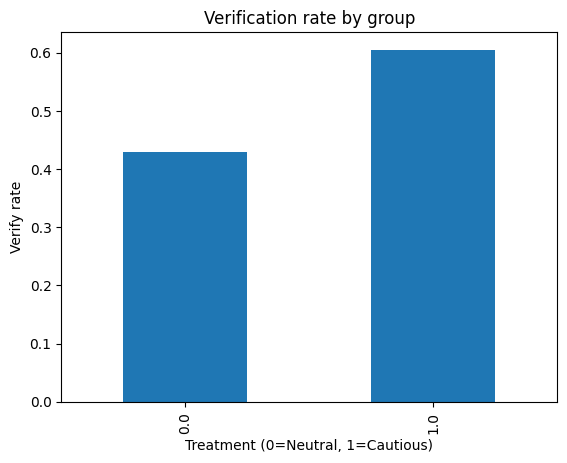

In [35]:
#create a chart
# verify rate by group
group_rates = data.groupby("treatment")["verification"].mean()
print(group_rates)

# optional: simple bar plot
import matplotlib.pyplot as plt
group_rates.plot(kind="bar")
plt.ylabel("Verify rate")
plt.xlabel("Treatment (0=Neutral, 1=Cautious)")
plt.title("Verification rate by group")
plt.show()